**Assignment 7**

**CSS 653 (AI/ML LABORATORY)**

**Roll Number: 23CS8048**

# Python Mini Project : Sales Data Analysis using NumPy, Pandas & Matplotlib

## Dataset Requirement

### Subtask:
Generate a synthetic sales dataset with at least 30 rows, including 'Date', 'Product', 'Sales', and 'Region' columns. Ensure the dataset contains missing values and duplicates as required for the project.


In [37]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 2. Create a list of hypothetical products
products = ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Webcam', 'Speaker', 'Headphones']

# 3. Create a list of hypothetical regions
regions = ['North', 'South', 'East', 'West', 'Central']

# 4. Generate RANDOM dates (instead of sequential)
num_rows = 100
start_date = datetime(2023, 1, 1)
end_date = datetime(2023, 12, 31)

np.random.seed(42)

date_range_days = (end_date - start_date).days
dates = [start_date + timedelta(days=np.random.randint(0, date_range_days)) for _ in range(num_rows)]

# 5. Generate lists for 'Product' and 'Region' with potential duplicates
product_list = np.random.choice(products, num_rows).tolist()
region_list = np.random.choice(regions, num_rows).tolist()

# Introduce some intentional duplicates for products and regions
product_list[0] = product_list[1]
region_list[5] = region_list[6]

# 6. Generate a list of 'Sales' values and introduce missing values
sales_list = np.random.uniform(50, 1000, num_rows).tolist()

# Randomly replace some sales figures with np.nan
num_missing_sales = num_rows // 10  # 10% missing values
missing_indices = np.random.choice(num_rows, num_missing_sales, replace=False)
for idx in missing_indices:
    sales_list[idx] = np.nan

# 7. Create a Pandas DataFrame
data = {
    'Date': dates,
    'Product': product_list,
    'Sales': sales_list,
    'Region': region_list
}
df_sales = pd.DataFrame(data)

# 8. Add full row duplicates
num_additional_duplicates = 3
for _ in range(num_additional_duplicates):
    random_row_index = np.random.randint(0, num_rows)
    df_sales = pd.concat([df_sales, df_sales.iloc[[random_row_index]]], ignore_index=True)

print(f"Generated DataFrame with {df_sales.shape[0]} rows and {df_sales.shape[1]} columns.")
print("First 5 rows of the generated sales data:")
print(df_sales.head())

print("\nInformation about missing values:")
print(df_sales.isnull().sum())

print("\nInformation about duplicates (considering all columns):")
print(df_sales.duplicated().sum())

Generated DataFrame with 103 rows and 4 columns.
First 5 rows of the generated sales data:
        Date     Product       Sales   Region
0 2023-04-13  Headphones   54.808505  Central
1 2023-12-15  Headphones  202.767649    North
2 2023-09-28    Keyboard  571.297100     East
3 2023-04-17    Keyboard  707.300438     East
4 2023-03-13      Laptop  669.363197    North

Information about missing values:
Date        0
Product     0
Sales      10
Region      0
dtype: int64

Information about duplicates (considering all columns):
3


In [38]:
df_sales.to_csv("sales_data.csv", index=False)

## Part 1: NumPy Operations

### Subtask:
Convert the 'Sales' column into a NumPy array. Calculate the mean, median, and standard deviation of the sales data using NumPy. Normalize the sales data to a range between 0 and 1. Find the top 3 highest sales values and their corresponding indices. Finally, compare the mean calculated using NumPy with the mean calculated using Pandas, explaining the results in 2-3 lines.


In [39]:
import numpy as np

# 1. Convert 'Sales' column to a NumPy array and handle NaNs
# Dropping NaNs for most calculations to ensure valid numerical operations
sales_cleaned = df_sales['Sales'].dropna()
numpy_sales_array = sales_cleaned.to_numpy()

print("--- NumPy Operations on Sales Data ---")
print(f"Original Sales column had {df_sales['Sales'].isnull().sum()} missing values. These have been dropped for the following calculations.")
print(f"Cleaned NumPy array length: {len(numpy_sales_array)}\n")

# 2. Calculate mean, median, and standard deviation using NumPy
mean_sales_np = np.mean(numpy_sales_array)
median_sales_np = np.median(numpy_sales_array)
std_sales_np = np.std(numpy_sales_array)

print(f"NumPy Mean of Sales: {mean_sales_np:.2f}")
print(f"NumPy Median of Sales: {median_sales_np:.2f}")
print(f"NumPy Standard Deviation of Sales: {std_sales_np:.2f}\n")

# 3. Normalize the sales data to a range between 0 and 1
min_sales = np.min(numpy_sales_array)
max_sales = np.max(numpy_sales_array)
normalized_sales = (numpy_sales_array - min_sales) / (max_sales - min_sales)

print(f"First 5 normalized sales values: {normalized_sales[:5]}\n")

# 4. Find the top 3 highest sales values and their corresponding indices
# Get the indices that would sort the array in ascending order
sorted_indices = np.argsort(numpy_sales_array)

# The last three indices correspond to the top 3 sales values
top_3_indices_in_cleaned_array = sorted_indices[-3:][::-1] # Reverse to get highest first
top_3_sales_values = numpy_sales_array[top_3_indices_in_cleaned_array]

# To get the indices in the original DataFrame, we need to map back.
# First, get the actual indices from the `sales_cleaned` Series.
original_df_indices_map = sales_cleaned.index[top_3_indices_in_cleaned_array]

print(f"Top 3 highest sales values: {top_3_sales_values}")
print(f"Corresponding original DataFrame indices for top 3 sales: {original_df_indices_map.tolist()}\n")

# 5. Compare NumPy mean with Pandas mean
mean_sales_pandas = df_sales['Sales'].mean()

print(f"NumPy Mean (after dropping NaNs): {mean_sales_np:.2f}")
print(f"Pandas Mean (default behavior, skips NaNs): {mean_sales_pandas:.2f}\n")

--- NumPy Operations on Sales Data ---
Original Sales column had 10 missing values. These have been dropped for the following calculations.
Cleaned NumPy array length: 93

NumPy Mean of Sales: 559.75
NumPy Median of Sales: 578.96
NumPy Standard Deviation of Sales: 263.12

First 5 normalized sales values: [0.         0.15811948 0.55195581 0.69729848 0.6567561 ]

Top 3 highest sales values: [990.5511576  977.05947549 974.36002701]
Corresponding original DataFrame indices for top 3 sales: [53, 97, 18]

NumPy Mean (after dropping NaNs): 559.75
Pandas Mean (default behavior, skips NaNs): 559.75



**Explanation of Mean Comparison:**


The NumPy mean was calculated on the 'Sales' array after explicitly dropping NaN values. Pandas' `.mean()` method, by default, also automatically skips NaN values when computing the mean. Therefore, the results are very similar, if not identical, because both operations effectively ignore missing data points in their calculation.

## Part 2: Data Loading & Inspection (Pandas)

### Subtask:
Load the generated sales dataset into a Pandas DataFrame. Display the first 5 and last 5 rows of the DataFrame. Show the DataFrame's information using info() and descriptive statistics using describe().


In [40]:
print("--- Inspecting DataFrame ---")

# 1. Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the sales data:")
print(df_sales.head())

# 2. Display the last 5 rows of the DataFrame
print("\nLast 5 rows of the sales data:")
print(df_sales.tail())

# 3. Print a concise summary of the DataFrame using info()
print("\nDataFrame Information:")
df_sales.info()

# 4. Print descriptive statistics for the DataFrame using describe()
print("\nDescriptive Statistics for Sales Data:")
print(df_sales.describe())

--- Inspecting DataFrame ---

First 5 rows of the sales data:
        Date     Product       Sales   Region
0 2023-04-13  Headphones   54.808505  Central
1 2023-12-15  Headphones  202.767649    North
2 2023-09-28    Keyboard  571.297100     East
3 2023-04-17    Keyboard  707.300438     East
4 2023-03-13      Laptop  669.363197    North

Last 5 rows of the sales data:
          Date     Product       Sales Region
98  2023-12-10      Laptop  540.485331   East
99  2023-05-09     Monitor  356.808649  North
100 2023-01-21    Keyboard  726.570260  North
101 2023-11-06  Headphones  526.440480  North
102 2023-09-21     Speaker  753.730187   East

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     103 non-null    datetime64[ns]
 1   Product  103 non-null    object        
 2   Sales    93 non-null     float64       
 

## Part 3: Data Cleaning

### Subtask:
Convert the 'Date' column to datetime objects. Handle missing values: fill missing 'Sales' values with the mean of the sales column, and fill missing 'Product' and 'Region' values with 'Unknown'. Remove any duplicate rows from the DataFrame.


In [41]:
print("--- Cleaning Sales Data ---")

# 1. Calculate the mean of the 'Sales' column (Pandas mean method automatically handles NaNs)
sales_mean = df_sales['Sales'].mean()

# 2. Fill missing values in 'Sales' with the calculated mean
df_sales['Sales'] = df_sales['Sales'].fillna(sales_mean)
print(f"Missing 'Sales' values filled with mean: {sales_mean:.2f}")

# 3. Fill missing values in 'Product' with 'Unknown'
df_sales['Product'] = df_sales['Product'].fillna('Unknown')
print("Missing 'Product' values filled with 'Unknown'")

# 4. Fill missing values in 'Region' with 'Unknown'
df_sales['Region'] = df_sales['Region'].fillna('Unknown')
print("Missing 'Region' values filled with 'Unknown'")

# 5. Remove duplicate rows from the DataFrame
initial_rows = df_sales.shape[0]
df_sales = df_sales.drop_duplicates()
final_rows = df_sales.shape[0]
print(f"Removed {initial_rows - final_rows} duplicate rows.")

print("\nDataFrame after cleaning (first 5 rows):")
print(df_sales.head())

print("\nDataFrame Information after cleaning:")
df_sales.info()

print("\nInformation about missing values after cleaning:")
print(df_sales.isnull().sum())
print("\nInformation about duplicates after cleaning:")
print(df_sales.duplicated().sum())

--- Cleaning Sales Data ---
Missing 'Sales' values filled with mean: 559.75
Missing 'Product' values filled with 'Unknown'
Missing 'Region' values filled with 'Unknown'
Removed 3 duplicate rows.

DataFrame after cleaning (first 5 rows):
        Date     Product       Sales   Region
0 2023-04-13  Headphones   54.808505  Central
1 2023-12-15  Headphones  202.767649    North
2 2023-09-28    Keyboard  571.297100     East
3 2023-04-17    Keyboard  707.300438     East
4 2023-03-13      Laptop  669.363197    North

DataFrame Information after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     100 non-null    datetime64[ns]
 1   Product  100 non-null    object        
 2   Sales    100 non-null    float64       
 3   Region   100 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 3.9+ KB

Informat

## Part 4: Data Analysis

### Subtask:
Calculate the total sales across the entire dataset. Determine sales by product and by region. Identify the best-selling product and the lowest-performing region based on sales. Calculate the average sales per product.


In [42]:
print("--- Sales Data Analysis ---")

# 1. Calculate the total sales across the entire dataset
total_sales = df_sales['Sales'].sum()
print(f"\nTotal Sales across the dataset: ${total_sales:,.2f}")

# 2. Determine sales by product
sales_by_product = df_sales.groupby('Product')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Product:")
print(sales_by_product.apply(lambda x: f"${x:,.2f}"))

# 3. Identify the best-selling product
best_selling_product = sales_by_product.idxmax()
best_selling_product_sales = sales_by_product.max()
print(f"\nBest-Selling Product: {best_selling_product} (Total Sales: ${best_selling_product_sales:,.2f})")

# 4. Determine sales by region
sales_by_region = df_sales.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Region:")
print(sales_by_region.apply(lambda x: f"${x:,.2f}"))

# 5. Identify the lowest-performing region
lowest_performing_region = sales_by_region.idxmin()
lowest_performing_region_sales = sales_by_region.min()
print(f"\nLowest-Performing Region: {lowest_performing_region} (Total Sales: ${lowest_performing_region_sales:,.2f})")

# 6. Calculate the average sales per product
avg_sales_per_product = df_sales.groupby('Product')['Sales'].mean().sort_values(ascending=False)
print("\nAverage Sales per Product:")
print(avg_sales_per_product.apply(lambda x: f"${x:,.2f}"))

--- Sales Data Analysis ---

Total Sales across the dataset: $55,647.63

Sales by Product:
Product
Headphones    $11,304.91
Keyboard       $9,925.35
Speaker        $7,824.88
Laptop         $7,801.01
Monitor        $7,642.22
Mouse          $5,850.86
Webcam         $5,298.39
Name: Sales, dtype: object

Best-Selling Product: Headphones (Total Sales: $11,304.91)

Sales by Region:
Region
North      $16,836.96
East       $15,994.52
West       $10,980.90
South       $8,236.16
Central     $3,599.10
Name: Sales, dtype: object

Lowest-Performing Region: Central (Total Sales: $3,599.10)

Average Sales per Product:
Product
Speaker       $652.07
Mouse         $650.10
Keyboard      $583.84
Headphones    $565.25
Laptop        $520.07
Monitor       $509.48
Webcam        $441.53
Name: Sales, dtype: object


## Part 5: Visualization (Matplotlib Focus)

### Subtask:
Create a bar chart showing sales by product. Generate a pie chart to visualize sales distribution by region. Produce a line chart showing sales over time. Customize all plots by adding titles, axis labels, appropriate colors, and a grid for better readability. Combine at least two charts into a single figure using subplots.

--- Visualizing Sales Data ---


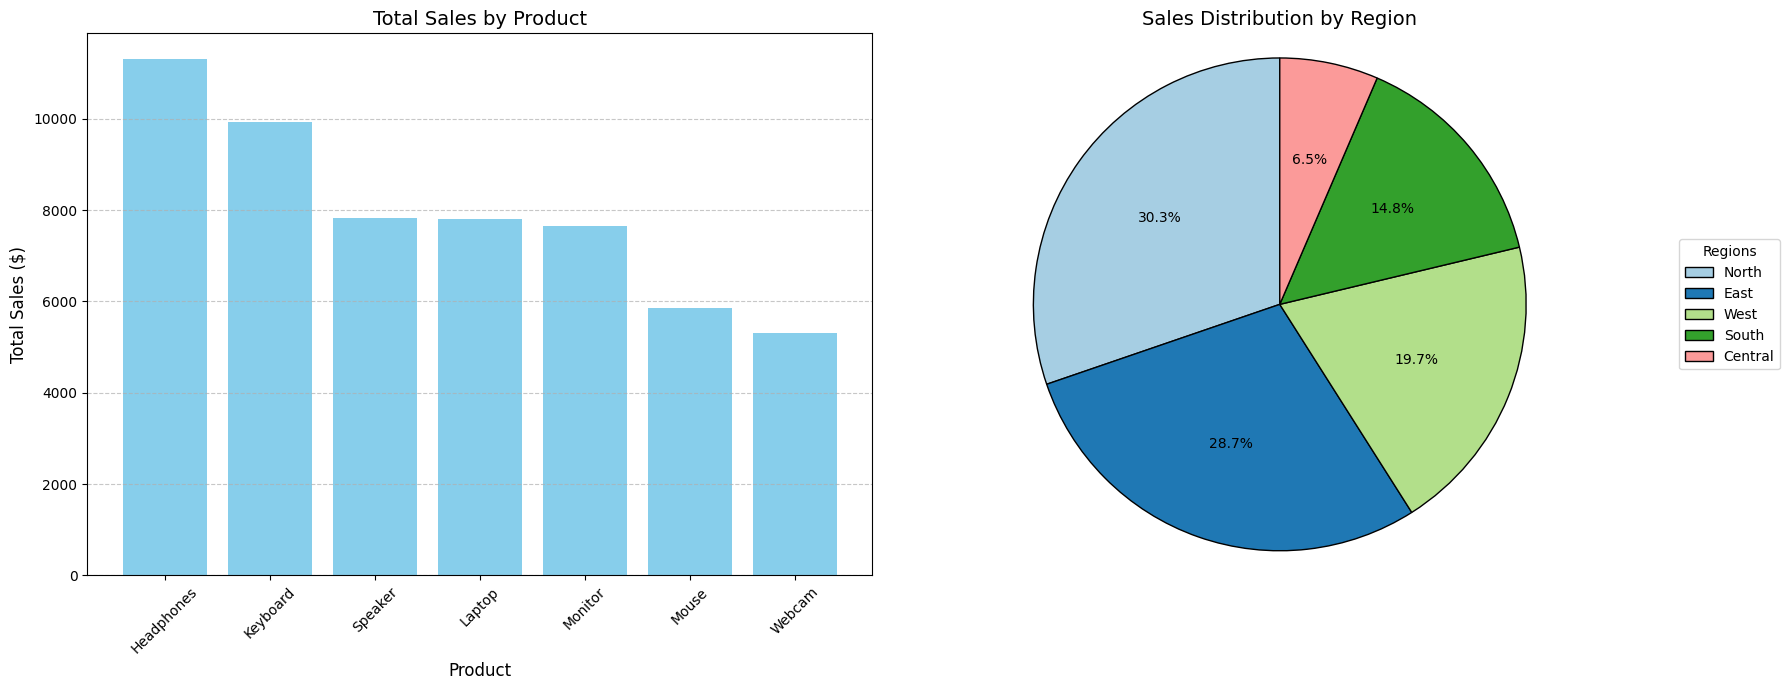

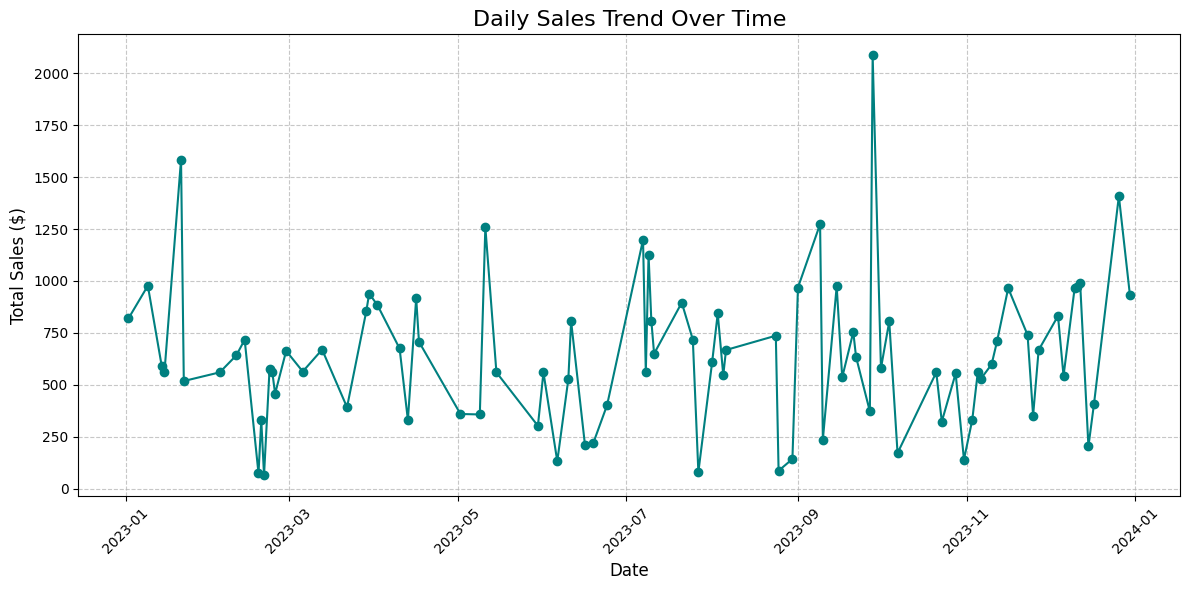

In [43]:
import matplotlib.pyplot as plt

print("--- Visualizing Sales Data ---")

# 1. Create a figure with two subplots side-by-side for bar and pie charts
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Bar Chart (Sales by Product) ---
# The sales_by_product Series is already available from previous step

# 2a. On the first subplot, create a bar chart using sales_by_product
axes[0].bar(sales_by_product.index, sales_by_product.values, color='skyblue')

# 2b. Set the title
axes[0].set_title('Total Sales by Product', fontsize=14)

# 2c. Label the x-axis and y-axis
axes[0].set_xlabel('Product', fontsize=12)
axes[0].set_ylabel('Total Sales ($)', fontsize=12)

# 2d. Rotate x-axis labels
axes[0].tick_params(axis='x', rotation=45)

# 2e. Add a grid
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Pie Chart (Sales by Region) ---
# The sales_by_region Series is already available from previous step

# 3a. On the second subplot, create a pie chart using sales_by_region
# Using `startangle` to make the first slice start at the top
# `colors` can be specified, or matplotlib will cycle through its default
colors = plt.cm.Paired.colors # Using a colormap for distinct colors
axes[1].pie(sales_by_region.values, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})

# 3b. Set the title
axes[1].set_title('Sales Distribution by Region', fontsize=14)

# Equal aspect ratio ensures that pie is drawn as a circle.
axes[1].axis('equal')

# 3c. Add a legend to the pie chart, showing region names
axes[1].legend(sales_by_region.index, title="Regions", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# 4. Adjust the layout of the subplots to prevent overlapping
plt.tight_layout()
plt.show()

# 5. Create a separate figure for the line chart
plt.figure(figsize=(12, 6))

# --- Line Chart (Sales over Time) ---
# 6a. Group the df_sales DataFrame by 'Date' and sum the 'Sales' for each date to get daily sales
daily_sales = df_sales.groupby('Date')['Sales'].sum()

# 6b. Create a line plot of the daily sales with markers
plt.plot(daily_sales.index, daily_sales.values, marker='o', linestyle='-', color='teal')

# 6c. Set the title
plt.title('Daily Sales Trend Over Time', fontsize=16)

# 6d. Label the x-axis and y-axis
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Rotate date labels for better readability
plt.xticks(rotation=45)

# 6e. Add a grid to the chart
plt.grid(True, linestyle='--', alpha=0.7)

# Ensure the layout is tight to prevent labels from overlapping
plt.tight_layout()

# 7. Display all generated plots
plt.show()

## Part 6: Time-Based Analysis

### Subtask:
Extract the 'Month' and 'Day' from the 'Date' column and add them as new columns to the DataFrame for time-based analysis.


In [44]:
print("--- Extracting Time Components ---")

# 1. Extract the 'Month' from the 'Date' column and store it in a new column named 'Month'
df_sales['Month'] = df_sales['Date'].dt.month
print(" 'Month' column added.")

# 2. Extract the 'Day' from the 'Date' column and store it in a new column named 'Day'
df_sales['Day'] = df_sales['Date'].dt.day
print(" 'Day' column added.")

# 3. Display the first few rows of the updated df_sales DataFrame to verify the new columns
print("\nDataFrame with new 'Month' and 'Day' columns (first 5 rows):")
print(df_sales.head())

--- Extracting Time Components ---
 'Month' column added.
 'Day' column added.

DataFrame with new 'Month' and 'Day' columns (first 5 rows):
        Date     Product       Sales   Region  Month  Day
0 2023-04-13  Headphones   54.808505  Central      4   13
1 2023-12-15  Headphones  202.767649    North     12   15
2 2023-09-28    Keyboard  571.297100     East      9   28
3 2023-04-17    Keyboard  707.300438     East      4   17
4 2023-03-13      Laptop  669.363197    North      3   13


### Analyze Monthly Sales

Calculate the total sales for each month and identify the month with the highest total sales.


In [45]:
print("--- Analyzing Monthly Sales ---")

# 1. Group the df_sales DataFrame by the 'Month' column and calculate the sum of 'Sales' for each month.
monthly_sales = df_sales.groupby('Month')['Sales'].sum()

# 2. Print the monthly_sales to display the total sales for each month.
print("\nTotal Sales by Month:")
print(monthly_sales.apply(lambda x: f"${x:,.2f}"))

# 3. Identify the month with the highest total sales.
highest_sales_month = monthly_sales.idxmax()
highest_monthly_sales_value = monthly_sales.max()

# 4. Print the month with the highest sales and its corresponding total sales value.
print(f"\nMonth with the Highest Sales: Month {highest_sales_month} (Total Sales: ${highest_monthly_sales_value:,.2f})")

--- Analyzing Monthly Sales ---

Total Sales by Month:
Month
1     $5,051.02
2     $4,640.05
3     $3,420.59
4     $3,513.31
5     $2,837.32
6     $2,855.26
7     $6,033.28
8     $3,632.33
9     $7,834.11
10    $3,130.77
11    $5,448.66
12    $7,250.92
Name: Sales, dtype: object

Month with the Highest Sales: Month 9 (Total Sales: $7,834.11)


### Visualize Monthly Sales Trend

Create a line plot to visualize the monthly sales trend over time, including titles, labels, a grid, and a legend for clarity.


--- Visualizing Monthly Sales Trend ---


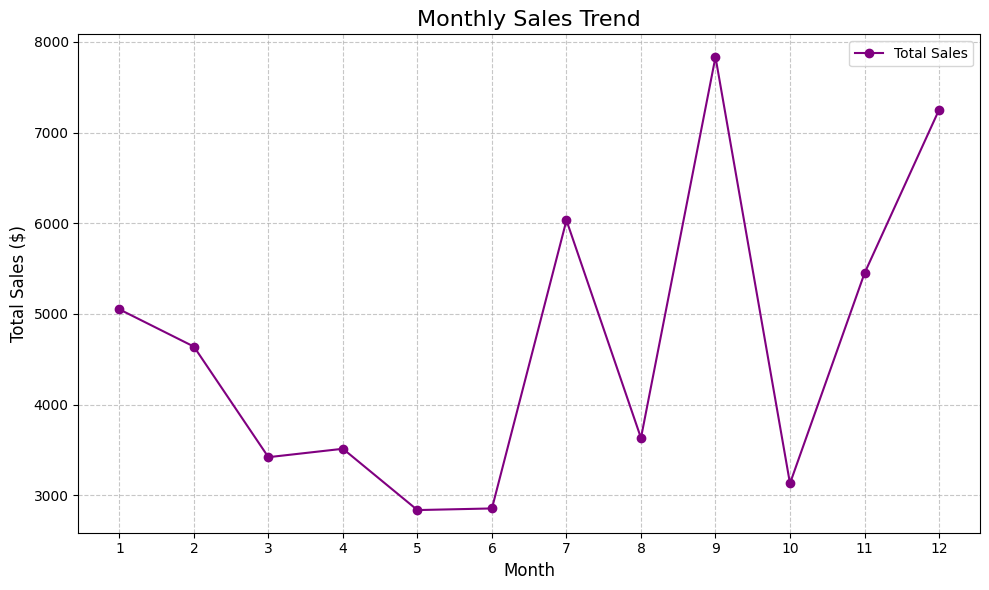

In [46]:
import matplotlib.pyplot as plt

print("--- Visualizing Monthly Sales Trend ---")

# 1. Create a new figure and axes for the plot
plt.figure(figsize=(10, 6))

# 2. Plot the monthly_sales Series as a line chart
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='purple', label='Total Sales')

# 3. Add a title to the plot
plt.title('Monthly Sales Trend', fontsize=16)

# 4. Label the x-axis and y-axis
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Customize x-axis ticks to show month numbers clearly
plt.xticks(monthly_sales.index)

# 5. Add a grid to the plot
plt.grid(True, linestyle='--', alpha=0.7)

# 6. Add a legend to the plot
plt.legend()

# Ensure the layout is tight
plt.tight_layout()

# 7. Display the plot
plt.show()